In [4]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.1.1-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 10.3 MB/s  0:00:00
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
Using cached numpy-2.4.3-cp311-c

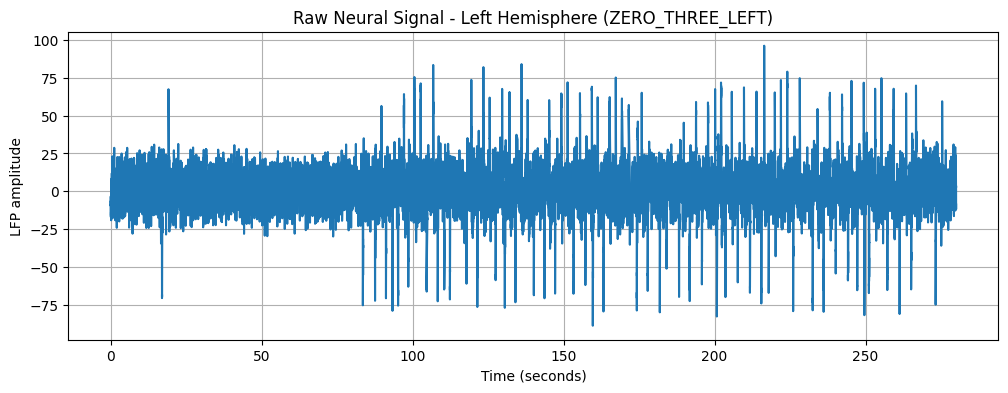

In [22]:
import json
import numpy as np
import matplotlib.pyplot as plt

file_path = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1426\Report_Json_Session_Report_20260305T151332.json"

with open(file_path, "r") as f:
    data = json.load(f)

# Find the LEFT channel block
left_block = None
for block in data["BrainSenseTimeDomain"]:
    if block["Channel"] == "ZERO_THREE_LEFT":
        left_block = block
        break

# Extract signal
signal = left_block["TimeDomainData"]
fs = left_block["SampleRateInHz"]

# Create time axis
time = np.arange(len(signal)) / fs

# Plot
plt.figure(figsize=(12,4))
plt.plot(time, signal)

plt.xlabel("Time (seconds)")
plt.ylabel("LFP amplitude")
plt.title("Raw Neural Signal - Left Hemisphere (ZERO_THREE_LEFT)")
plt.grid(True)

plt.show()

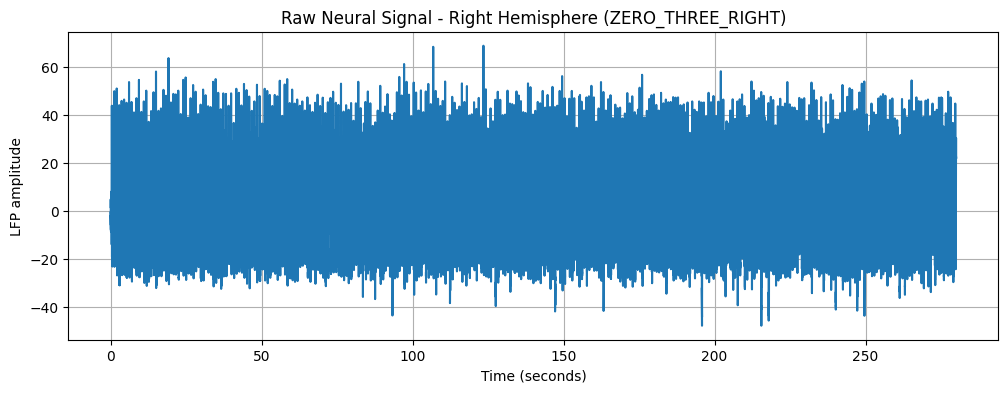

In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt

file_path = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1426\Report_Json_Session_Report_20260305T151332.json"


with open(file_path, "r") as f:
    data = json.load(f)

# Find the RIGHT channel block
right_block = None
for block in data["BrainSenseTimeDomain"]:
    if block["Channel"] == "ZERO_THREE_RIGHT":
        right_block = block
        break

# Extract signal
signal = right_block["TimeDomainData"]
fs = right_block["SampleRateInHz"]

# Create time axis
time = np.arange(len(signal)) / fs

# Plot
plt.figure(figsize=(12,4))
plt.plot(time, signal)

plt.xlabel("Time (seconds)")
plt.ylabel("LFP amplitude")
plt.title("Raw Neural Signal - Right Hemisphere (ZERO_THREE_RIGHT)")
plt.grid(True)

plt.show()

In [19]:
import json

file = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1426\Report_Json_Session_Report_20260305T151332.json"

with open(file) as f:
    data = json.load(f)

events = []

for block in data["BrainSenseLfp"]:

    for row in block["LfpData"]:
        t = row["TicksInMs"]
        stim = row["Left"]["mA"]

        state = "ON" if stim > 0 else "OFF"
        events.append((t, stim, state))


prev_state = None

for t, stim, state in events:

    if prev_state is None:
        prev_state = state
        continue

    if state != prev_state:
        print(f"State change at {t} ms → {state} (amplitude {stim} mA)")
        prev_state = state

State change at 798750 ms → ON (amplitude 0.1 mA)
State change at 801250 ms → OFF (amplitude 0 mA)
State change at 865250 ms → ON (amplitude 0.1 mA)
State change at 953750 ms → OFF (amplitude 0 mA)
State change at 956250 ms → ON (amplitude 0.1 mA)
State change at 957750 ms → OFF (amplitude 0 mA)
State change at 959750 ms → ON (amplitude 0.1 mA)
State change at 1005750 ms → OFF (amplitude 0 mA)
State change at 1007750 ms → ON (amplitude 0.1 mA)
State change at 1010250 ms → OFF (amplitude 0 mA)
State change at 1014250 ms → ON (amplitude 0.1 mA)
State change at 1016250 ms → OFF (amplitude 0 mA)
State change at 1018250 ms → ON (amplitude 0.1 mA)
State change at 1020250 ms → OFF (amplitude 0 mA)
State change at 1022250 ms → ON (amplitude 0.1 mA)
State change at 1024250 ms → OFF (amplitude 0 mA)
State change at 1026250 ms → ON (amplitude 0.1 mA)
State change at 1027250 ms → OFF (amplitude 0 mA)
State change at 1029250 ms → ON (amplitude 0.1 mA)
State change at 1031250 ms → OFF (amplitude 0 m

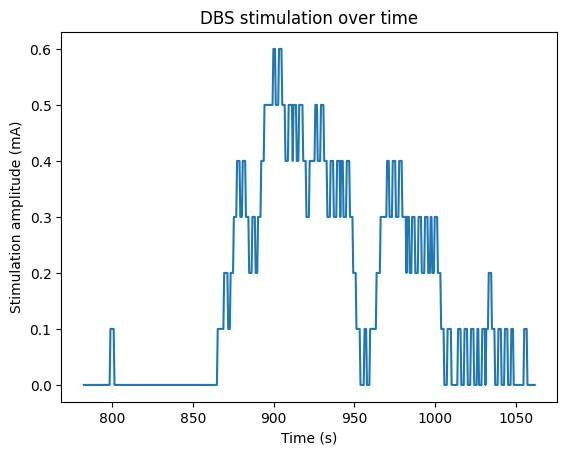

In [24]:
import matplotlib.pyplot as plt

times = []
stim = []

for block in data["BrainSenseLfp"]:
    for row in block["LfpData"]:
        times.append(row["TicksInMs"]/1000)
        stim.append(row["Left"]["mA"])

plt.plot(times, stim)
plt.xlabel("Time (s)")
plt.ylabel("Stimulation amplitude (mA)")
plt.title("DBS stimulation over time")
plt.show()